# V3.2 Adaptive Router для Pair Generator

В этом ноутбуке сравнивается новая стратегия `adaptive_router_v32` с уже проверенными подходами:

- `random`
- `uncertainty_axis`
- `semantic_active_v21`
- `candidate_pool_active`
- `hybrid_active_v21`

`adaptive_router_v32` не является Preference Model. Это эвристический маршрутизатор внутри Pair Generator: он выбирает, какой генератор вопроса использовать на текущем шаге — `semantic_active_v21`, `candidate_pool_active` или `uncertainty_axis`.

In [8]:
from personalization.plotting import use_article_style
from pathlib import Path
import sys

import numpy as np
pandas_imported = False
import pandas as pd
import matplotlib.pyplot as plt

# Если ноутбук запущен из research/notebooks, поднимаемся на уровень research.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from personalization.synthetic_dataset import (
    generate_synthetic_users_dataset,
    load_synthetic_users_dataset,
    save_synthetic_users_dataset,
    dataset_metadata,
)
from personalization.batch_eval import (
    run_batch_on_dataset,
    summarize_by_strategy,
    win_rates_vs_baseline,
)
from personalization.analysis import (
    display_strategy_name,
    display_group_name,
    merge_sessions_with_user_metadata,
    summarize_by_group,
    winners_by_group,
    win_rates_vs_baseline_by_group,
    compare_two_strategies_by_group,
    win_rate_between_strategies_by_group,
)
use_article_style()


## 1. Загрузка фиксированного synthetic user dataset

Все стратегии тестируются на одном и том же наборе пользователей. Если dataset отсутствует, он будет сгенерирован автоматически.

In [2]:
DATASET_PATH = PROJECT_ROOT / "outputs" / "datasets" / "synthetic_users_v21.csv"
DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)

if DATASET_PATH.exists():
    dataset = load_synthetic_users_dataset(DATASET_PATH)
else:
    dataset = generate_synthetic_users_dataset(
        n_per_mode=100,
        seed=42,
        noise_std=0.05,
    )
    save_synthetic_users_dataset(
        dataset=dataset,
        dataset_path=DATASET_PATH,
        metadata_path=DATASET_PATH.with_suffix(".metadata.json"),
        metadata=dataset_metadata(
            dataset_name=DATASET_PATH.stem,
            n_per_mode=100,
            seed=42,
            noise_std=0.05,
            importance_sigma=0.35,
        ),
    )

dataset["target_mode"].value_counts()

target_mode
random8d       100
semantic4d     100
semantic6d     100
archetype8d    100
Name: count, dtype: int64

## 2. Batch-тест стратегий

Новая стратегия `adaptive_router_v32` сравнивается с лучшими предыдущими подходами.

In [3]:
STRATEGIES = [
    "random",
    "uncertainty_axis",
    "semantic_control_v21",
    "semantic_active_v21",
    "candidate_pool_active",
    "adaptive_router_v32",
    "hybrid_active_v21",
]

sessions_df, curves = run_batch_on_dataset(
    dataset=dataset,
    strategies=STRATEGIES,
    n_steps=25,
    step_scale=0.6,
    lr=0.25,
)

strategy_summary = summarize_by_strategy(sessions_df)
win_rates = win_rates_vs_baseline(sessions_df, baseline="random")

strategy_summary

,target_mode,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
4,archetype8d,semantic_active_v21,100,1.102635,0.378947,0.133465,0.280561,0.578662,57.677776,24.221786
0,archetype8d,adaptive_router_v32,100,1.102635,0.399598,0.131814,0.281313,0.582443,54.344613,27.860198
5,archetype8d,semantic_control_v21,100,1.102635,0.476987,0.164772,0.322239,0.616510,44.705813,38.626852
1,archetype8d,candidate_pool_active,100,1.102635,0.486661,0.172475,0.348718,0.641229,43.705720,36.310704
2,archetype8d,hybrid_active_v21,100,1.102635,0.513053,0.170899,0.390215,0.700265,40.332236,39.495013
6,archetype8d,uncertainty_axis,100,1.102635,0.533740,0.259131,0.443866,0.760355,41.021812,35.416559
3,archetype8d,random,100,1.102635,0.567765,0.214612,0.472785,0.770912,35.841547,41.039317
13,random8d,uncertainty_axis,100,2.212002,0.985761,0.415946,0.960684,1.546811,56.663880,11.459939
8,random8d,candidate_pool_active,100,2.212002,0.992587,0.426057,0.975984,1.562093,56.254310,11.525204
10,random8d,random,100,2.212002,0.996708,0.402072,0.979050,1.572826,55.800212,11.632861


In [4]:
win_rates

,target_mode,strategy,baseline,win_rate_final_distance,win_rate_best_distance
0,archetype8d,adaptive_router_v32,random,0.84,0.93
1,archetype8d,candidate_pool_active,random,0.63,0.82
2,archetype8d,hybrid_active_v21,random,0.60,0.62
3,archetype8d,semantic_active_v21,random,0.88,0.94
4,archetype8d,semantic_control_v21,random,0.65,0.79
5,archetype8d,uncertainty_axis,random,0.61,0.58
6,random8d,adaptive_router_v32,random,0.12,0.13
7,random8d,candidate_pool_active,random,0.57,0.60
8,random8d,hybrid_active_v21,random,0.45,0.47
9,random8d,semantic_active_v21,random,0.11,0.12


## 3. Сохранение таблиц

In [5]:
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
PREFIX = "notebook_v32_adaptive_router"

sessions_df.to_csv(METRICS_DIR / f"{PREFIX}_sessions.csv", index=False)
strategy_summary.to_csv(METRICS_DIR / f"{PREFIX}_strategy_summary.csv", index=False)
win_rates.to_csv(METRICS_DIR / f"{PREFIX}_win_rates.csv", index=False)

print("Saved to:", METRICS_DIR)

Saved to: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\metrics


## 4. Среднее финальное расстояние по режимам target

Чем меньше `mean_final_distance`, тем ближе финальный `preference state` к скрытому target пользователя.

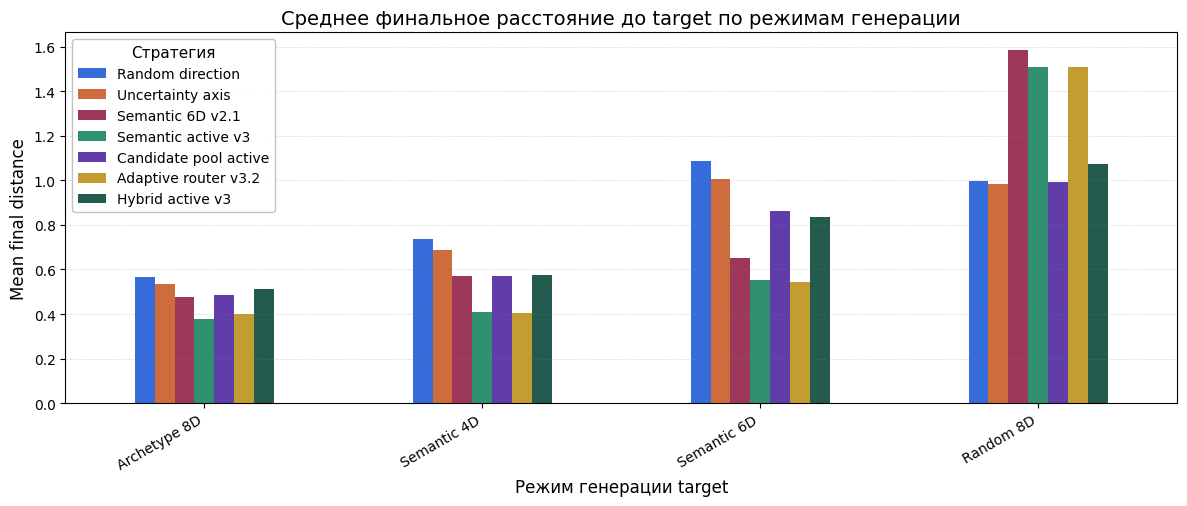

In [9]:
def plot_mean_final_distance_by_mode(strategy_summary: pd.DataFrame):
    modes = [m for m in ["archetype8d", "semantic4d", "semantic6d", "random8d"] if m in strategy_summary["target_mode"].unique()]
    strategies = [s for s in STRATEGIES if s in strategy_summary["strategy"].unique()]

    table = strategy_summary.pivot(
        index="target_mode",
        columns="strategy",
        values="mean_final_distance",
    ).loc[modes, strategies]

    fig, ax = plt.subplots(figsize=(12, 5.2), facecolor="white")
    table.rename(index=display_group_name, columns=display_strategy_name).plot(kind="bar", ax=ax)

    ax.set_title("Среднее финальное расстояние до target по режимам генерации")
    ax.set_xlabel("Режим генерации target")
    ax.set_ylabel("Mean final distance")
    ax.grid(True, axis="y", alpha=0.3, linestyle="--", color="gray")
    ax.legend(title="Стратегия", frameon=True, facecolor="white", edgecolor="0.75")
    ax.tick_params(axis="x", labelrotation=30)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    plt.tight_layout()
    plt.show()

plot_mean_final_distance_by_mode(strategy_summary)

## 5. Средняя сходимость по режимам target

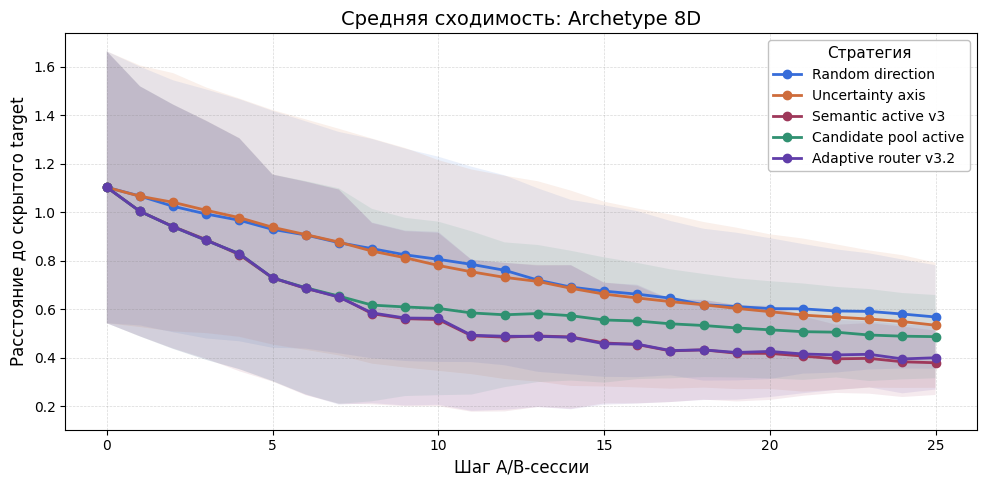

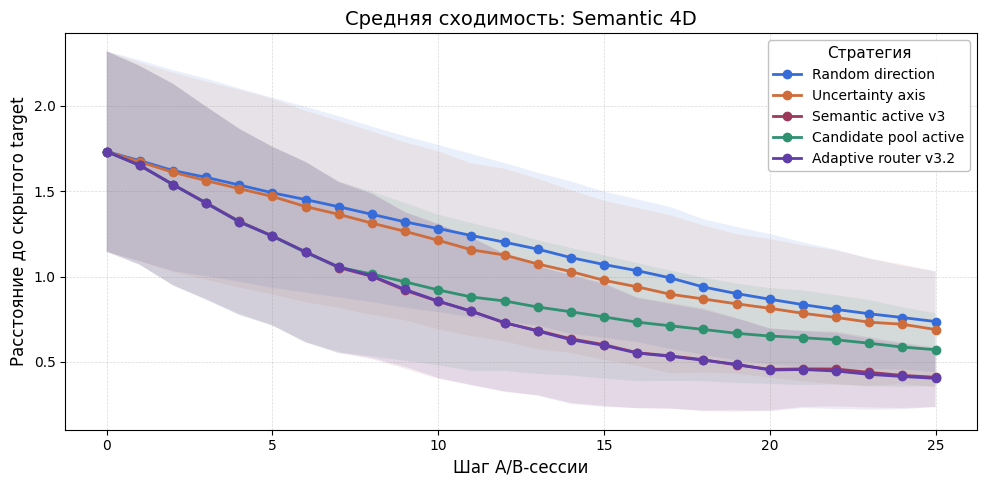

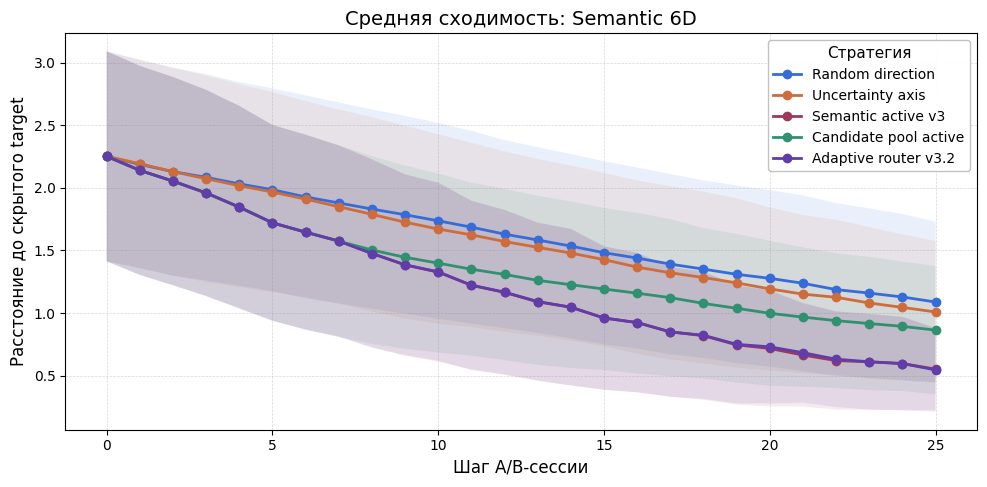

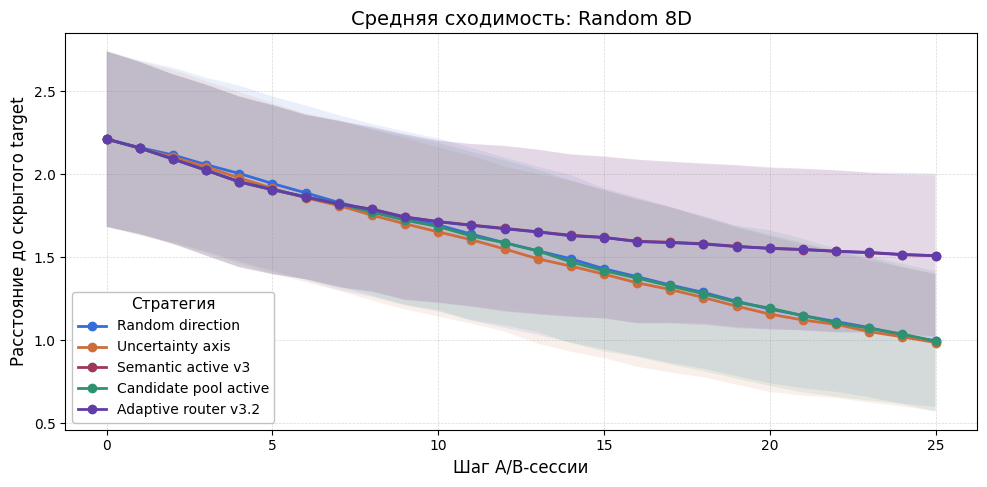

In [10]:
def plot_mean_convergence(curves: dict, target_mode: str, strategies: list[str]):
    fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")

    for strategy in strategies:
        if target_mode not in curves or strategy not in curves[target_mode]:
            continue
        values = curves[target_mode][strategy]
        mean = values.mean(axis=0)
        std = values.std(axis=0)
        steps = np.arange(len(mean))

        ax.plot(steps, mean, marker="o", linewidth=2, label=display_strategy_name(strategy))
        ax.fill_between(steps, mean - std, mean + std, alpha=0.10)

    ax.set_title(f"Средняя сходимость: {display_group_name(target_mode)}")
    ax.set_xlabel("Шаг A/B-сессии")
    ax.set_ylabel("Расстояние до скрытого target")
    ax.grid(True, alpha=0.3, linestyle="--", color="gray")
    ax.legend(title="Стратегия", frameon=True, facecolor="white", edgecolor="0.75")
    plt.tight_layout()
    plt.show()

PLOT_STRATEGIES = [
    "random",
    "uncertainty_axis",
    "semantic_active_v21",
    "candidate_pool_active",
    "adaptive_router_v32",
]

for mode in ["archetype8d", "semantic4d", "semantic6d", "random8d"]:
    if mode in curves:
        plot_mean_convergence(curves, mode, PLOT_STRATEGIES)

## 6. Детальный анализ по группам пользователей

In [11]:
sessions_with_meta = merge_sessions_with_user_metadata(sessions_df, dataset)
sessions_with_meta.to_csv(METRICS_DIR / f"{PREFIX}_sessions_with_meta.csv", index=False)

target_mode_summary = summarize_by_group(sessions_with_meta, ["target_mode"])
target_mode_winners = winners_by_group(target_mode_summary, ["target_mode"])
target_mode_win_rates = win_rates_vs_baseline_by_group(sessions_with_meta, ["target_mode"])

target_mode_summary.to_csv(METRICS_DIR / f"{PREFIX}_target_mode_group_summary.csv", index=False)
target_mode_winners.to_csv(METRICS_DIR / f"{PREFIX}_target_mode_winners.csv", index=False)
target_mode_win_rates.to_csv(METRICS_DIR / f"{PREFIX}_target_mode_win_rates.csv", index=False)

target_mode_winners

,target_mode,winner_strategy,users,winner_mean_final_distance
0,archetype8d,semantic_active_v21,100,0.378947
1,semantic4d,adaptive_router_v32,100,0.403563
2,semantic6d,adaptive_router_v32,100,0.545524
3,random8d,uncertainty_axis,100,0.985761


In [12]:
archetype_sessions = sessions_with_meta[sessions_with_meta["target_mode"] == "archetype8d"].copy()

intensity_summary = summarize_by_group(archetype_sessions, ["intensity_label"])
intensity_win_rates = win_rates_vs_baseline_by_group(archetype_sessions, ["intensity_label"])
main_archetype_summary = summarize_by_group(archetype_sessions, ["main_archetype"])
main_archetype_win_rates = win_rates_vs_baseline_by_group(archetype_sessions, ["main_archetype"])

intensity_summary.to_csv(METRICS_DIR / f"{PREFIX}_intensity_group_summary.csv", index=False)
intensity_win_rates.to_csv(METRICS_DIR / f"{PREFIX}_intensity_win_rates.csv", index=False)
main_archetype_summary.to_csv(METRICS_DIR / f"{PREFIX}_main_archetype_group_summary.csv", index=False)
main_archetype_win_rates.to_csv(METRICS_DIR / f"{PREFIX}_main_archetype_win_rates.csv", index=False)

main_archetype_summary.head()

,main_archetype,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
4,bass_lover,semantic_active_v21,7,1.077502,0.332930,0.104913,0.258589,0.503561,67.679806,10.072760
0,bass_lover,adaptive_router_v32,7,1.077502,0.357661,0.105451,0.275787,0.520428,65.424223,9.549154
3,bass_lover,random,7,1.077502,0.397822,0.135922,0.357954,0.691390,58.330740,29.236898
2,bass_lover,hybrid_active_v21,7,1.077502,0.440470,0.138571,0.375178,0.641995,54.351592,22.581634
6,bass_lover,uncertainty_axis,7,1.077502,0.454155,0.144945,0.414871,0.706812,55.433790,16.929935


## 7. Adaptive router vs Semantic active / Candidate pool

In [14]:
router_vs_v3_by_archetype = compare_two_strategies_by_group(
    main_archetype_summary,
    group_col="main_archetype",
    old_strategy="semantic_active_v21",
    new_strategy="adaptive_router_v32",
    metric="mean_final_distance",
)

router_vs_candidate_by_archetype = compare_two_strategies_by_group(
    main_archetype_summary,
    group_col="main_archetype",
    old_strategy="candidate_pool_active",
    new_strategy="adaptive_router_v32",
    metric="mean_final_distance",
)

router_vs_v3_win_rates = win_rate_between_strategies_by_group(
    archetype_sessions,
    group_cols=["main_archetype"],
    strategy_a="adaptive_router_v32",
    strategy_b="semantic_active_v21",
    metric="final_distance",
)

router_vs_candidate_win_rates = win_rate_between_strategies_by_group(
    archetype_sessions,
    group_cols=["main_archetype"],
    strategy_a="adaptive_router_v32",
    strategy_b="candidate_pool_active",
    metric="final_distance",
)

router_vs_v3_by_archetype.to_csv(METRICS_DIR / f"{PREFIX}_router_vs_v3_by_archetype.csv", index=False)
router_vs_candidate_by_archetype.to_csv(METRICS_DIR / f"{PREFIX}_router_vs_candidate_by_archetype.csv", index=False)
router_vs_v3_win_rates.to_csv(METRICS_DIR / f"{PREFIX}_router_vs_v3_win_rates_by_archetype.csv", index=False)
router_vs_candidate_win_rates.to_csv(METRICS_DIR / f"{PREFIX}_router_vs_candidate_win_rates_by_archetype.csv", index=False)

router_vs_v3_by_archetype

,main_archetype,semantic_active_v21_mean_final_distance,adaptive_router_v32_mean_final_distance,improvement_abs,improvement_pct,winner
0,sparkle_lover,0.376305,0.310917,0.065388,17.376277,adaptive_router_v32
1,basshead,0.455611,0.440487,0.015124,3.319431,adaptive_router_v32
2,bright,0.387623,0.375437,0.012186,3.143798,adaptive_router_v32
3,extreme_vshape,0.549841,0.552700,-0.002859,-0.519975,semantic_active_v21
4,soft_dark,0.387104,0.395496,-0.008392,-2.167990,semantic_active_v21
5,club_curve,0.419631,0.428636,-0.009005,-2.145905,semantic_active_v21
6,neutral,0.297099,0.311297,-0.014198,-4.779019,semantic_active_v21
7,warm,0.323048,0.343503,-0.020455,-6.331855,semantic_active_v21
8,bass_lover,0.332930,0.357661,-0.024730,-7.428085,semantic_active_v21
9,v_shape,0.424585,0.462085,-0.037500,-8.832107,semantic_active_v21


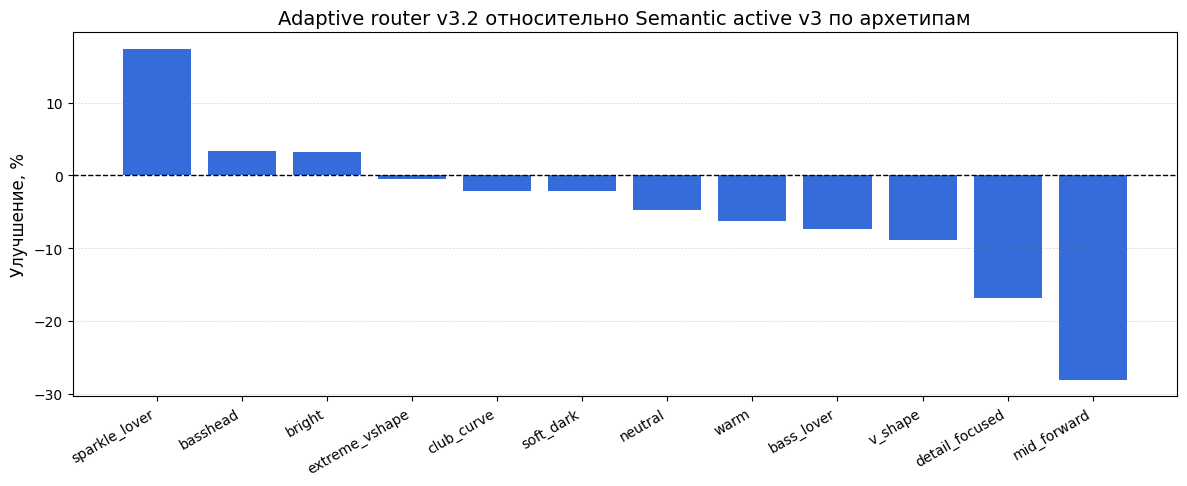

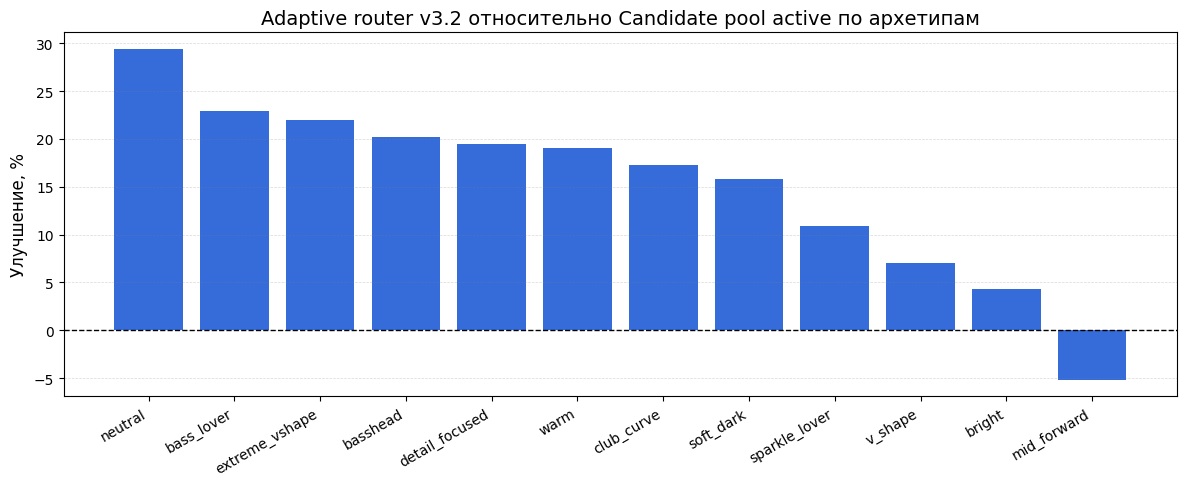

In [15]:
def plot_improvement_table(df: pd.DataFrame, group_col: str, title: str):
    plot_df = df.sort_values("improvement_pct", ascending=False).copy()
    fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")
    ax.bar(plot_df[group_col].astype(str), plot_df["improvement_pct"])
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Улучшение, %")
    ax.grid(True, axis="y", alpha=0.3, linestyle="--", color="gray")
    ax.tick_params(axis="x", labelrotation=30)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    plt.tight_layout()
    plt.show()

plot_improvement_table(
    router_vs_v3_by_archetype,
    group_col="main_archetype",
    title="Adaptive router v3.2 относительно Semantic active v3 по архетипам",
)

plot_improvement_table(
    router_vs_candidate_by_archetype,
    group_col="main_archetype",
    title="Adaptive router v3.2 относительно Candidate pool active по архетипам",
)

## Интерпретация

`adaptive_router_v32` проверяет гипотезу, что вместо одной фиксированной стратегии можно маршрутизировать A/B-вопросы между несколькими генераторами:

- `semantic_active_v21` — если текущая траектория похожа на semantic-подпространство;
- `candidate_pool_active` — если нужен смешанный universal exploration;
- `uncertainty_axis` — если неопределённость сконцентрирована на одной raw 8D-оси.

Если `adaptive_router_v32` приблизится к `semantic_active_v21` на `archetype8d` и одновременно будет лучше на `random8d`, это будет аргументом в пользу adaptive routing. Если нет — текущий вывод остаётся таким: для реалистичных пользователей основным Pair Generator лучше оставить `semantic_active_v21`, а `candidate_pool_active` использовать как universal fallback.